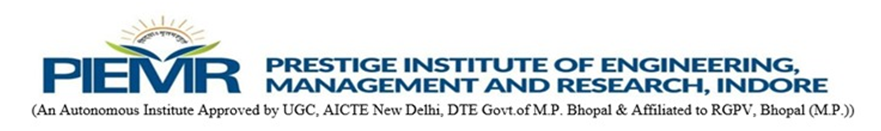

<h2 align="left">Department of Computer Science & Engineering [Internet of Things & Cybersecurity Including Blockchain Technology]</h2>

<h2 align="left">Data Analyatics in IoT & Blockchain </h2>

<h2 align="left"> Course Instructor: Dr. Rajesh Kumar</h2>

#### <h2 align="left">Experiment 4</h2>

<h2 align="left"> K Means Clustering </h2>

<h2 align="Left">Objective</h2>

To implement the K-Means Clustering Algorithm for customer segmentation using the Mall Customers dataset.

What is K-Means Clustering?


K-Means is an unsupervised machine learning algorithm used to divide data into clusters based on similarity.


The algorithm:

selects cluster centroids

calculates distances

assigns points to nearest centroid

updates centroids iteratively

Applications of K-Means

Customer segmentation

Market analysis

Recommendation systems


Python Libraries Used

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score




STEP 1: Load Dataset


In [21]:
path = r"C:\Users\rjesh\Mall_Customers.csv"

df = pd.read_csv(path)

print(df.head())





   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


STEP 2: Explore Dataset

In [22]:
print("Dataset Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nDataset Information:\n")
print(df.info())




Dataset Shape: (200, 5)

Columns:

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


Explanation

| Feature                | Meaning                    |
| ---------------------- | -------------------------- |
| CustomerID             | Customer ID                |
| Gender                 | Male/Female                |
| Age                    | Customer age               |
| Annual Income (k$)     | Annual income              |
| Spending Score (1-100) | Customer spending behavior |




STEP 3: Visualize Dataset 

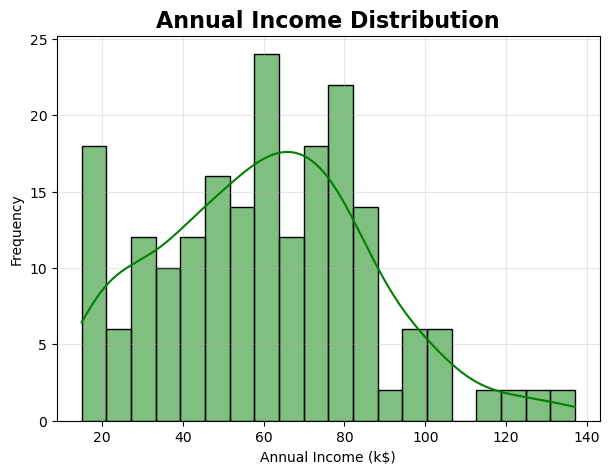

In [23]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['Annual Income (k$)'],
    bins=20,
    kde=True,
    color='green'
)

plt.title(
    "Annual Income Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()





Spending Score Distribution

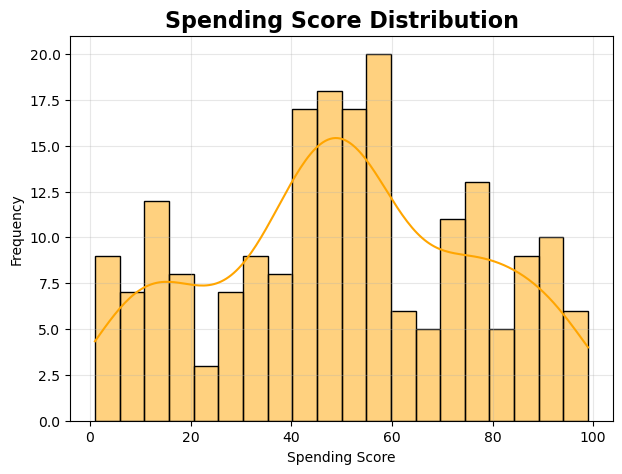

In [24]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['Spending Score (1-100)'],
    bins=20,
    kde=True,
    color='orange'
)

plt.title(
    "Spending Score Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Spending Score")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()




Income vs Spending Scatter Plot


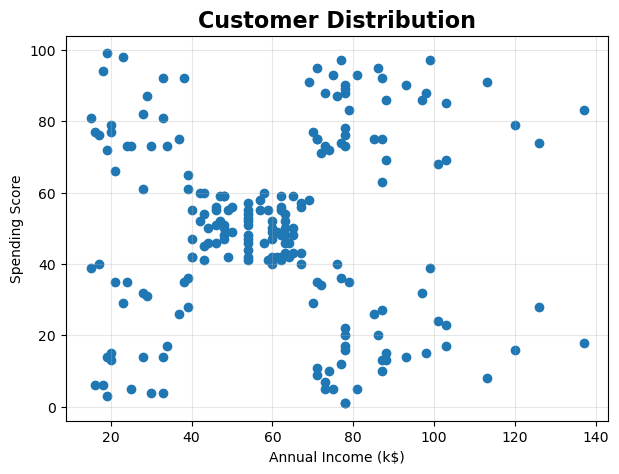

In [25]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.title(
    "Customer Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.grid(alpha=0.3)

plt.show()





STEP 4: Select Features

We use:

Annual Income
Spending Score

for customer segmentation.

In [26]:
X = df[
    [
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
]




STEP 5: Feature Scaling

Scaling improves clustering performance.

In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)





📖 Why Scaling?

Because:

income and spending may have different ranges
scaling prevents dominance of larger values
📉 STEP 6: Elbow Method

Elbow Method helps determine optimal K value.

📊 WCSS Formula

WCSS = Within Cluster Sum of Squares

Lower WCSS means better clustering.


In [28]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)



C:\Users\rjesh\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rjesh\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rjesh\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rjesh\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Plot Elbow Graph

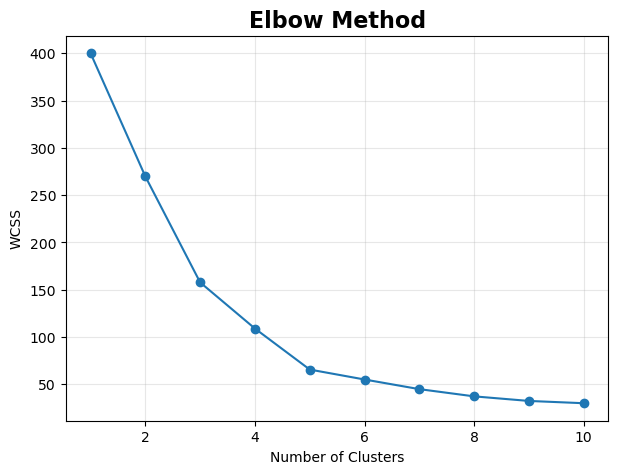

In [29]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title(
    "Elbow Method",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(alpha=0.3)

plt.show()




📖 Explanation

The elbow point indicates:

optimal number of clusters

Usually:

K = 5

for Mall Customers dataset.

In [30]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)




C:\Users\rjesh\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


STEP 7: Apply K-Means Clustering

In [31]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)





C:\Users\rjesh\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


STEP 8: Add Cluster Labels

In [32]:
df['Cluster'] = clusters

print(df.head())





   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


Explanation


Each customer is assigned to a cluster:


0

1

2

3

4





STEP 9: Visualize Clusters

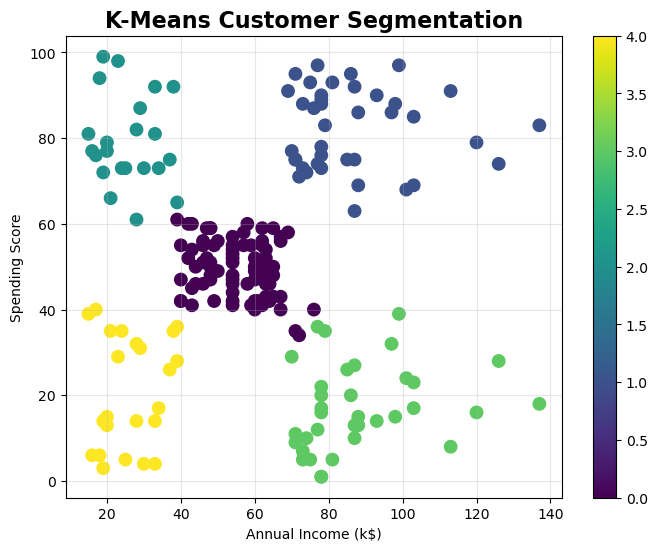

In [33]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=80
)

plt.title(
    "K-Means Customer Segmentation",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.colorbar(scatter)

plt.grid(alpha=0.3)

plt.show()





STEP 10: Visualize Centroids

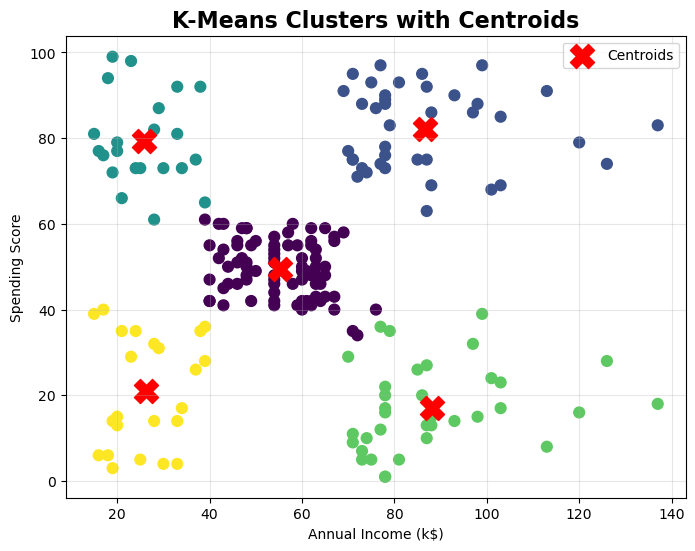

In [34]:
centroids = scaler.inverse_transform(
    kmeans.cluster_centers_
)

plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=60
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    color='red',
    marker='X',
    label='Centroids'
)

plt.title(
    "K-Means Clusters with Centroids",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.legend()

plt.grid(alpha=0.3)

plt.show()





📖 What are Centroids?

Centroids are:

cluster centers
average positions of cluster points

K-Means continuously updates centroids during training.

📈 STEP 11: Silhouette Score


Silhouette Score measures clustering quality.`



In [35]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)




Silhouette Score: 0.5546571631111091


| Score   | Meaning              |
| ------- | -------------------- |
| Near +1 | Excellent clustering |
| Near 0  | Overlapping clusters |
| Near -1 | Poor clustering      |




STEP 12: Cluster-wise Customer Count

In [36]:
print(df['Cluster'].value_counts())  



0    81
1    39
3    35
4    23
2    22
Name: Cluster, dtype: int64


STEP 13: Cluster-wise Boxplot

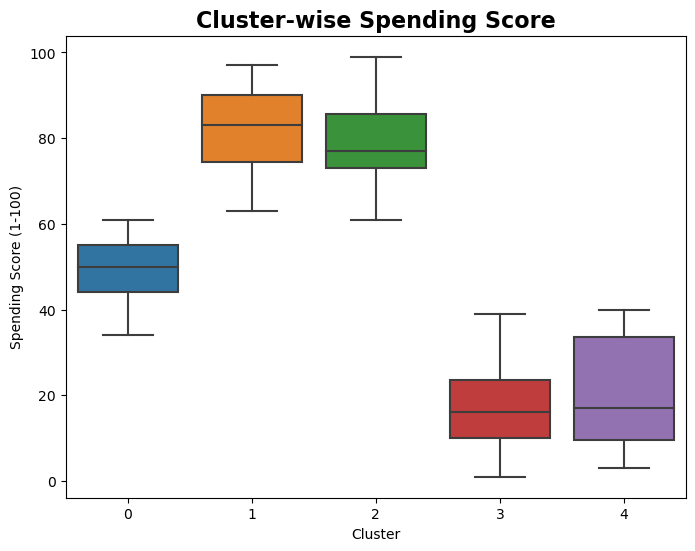

In [37]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Cluster',
    y='Spending Score (1-100)',
    data=df
)

plt.title(
    "Cluster-wise Spending Score",
    fontsize=16,
    fontweight='bold'
)

plt.show()




📊 Final Result


The K-Means clustering algorithm successfully segmented mall customers into different groups based on annual income and spending behavior.

✅ Advantages of K-Means

Simple and fast

Efficient for large datasets

Easy visualization

Widely used in industry

❌ Limitations

Requires predefined K value

Sensitive to outliers

Works best with spherical clusters

🎤 Viva Questions

Q1. What is K-Means clustering?


K-Means is an unsupervised clustering algorithm.


Q2. What is centroid?

Centroid is the center of a cluster.


Q3. What is WCSS?


Within Cluster Sum of Squares.

Q4. Why Elbow Method is used?


To determine optimal number of clusters.


Q5. Why scaling is important?


To normalize feature ranges.

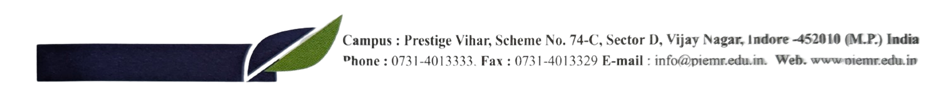